<center><img src='./Figs/cs-logo.png' width=200></center>



<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center>TP5 : Création d'un panorama </center>
<hr style=" border:none; height:3px;">
</h1>







L'objectif de ce Lab est de créer un panorama à partir de plusieurs images, en utilisant les principales notions vues en cours.

Le principe est relativement simple et suit l'approche vue en cours :

 + Une première étape est de décider quelle sera votre image source et quelles seront vos images destination (i.e les images que vous voulez mettre en correspondance avec votre image source).
 
 + Une fois l'image source choisie, une technique pour la création de panorama est de placer cette image dans un plus gros canevas (image de plus grande taille dont les pixels non connus seront mis à noir). La fonction [**warpAffine**]( https://docs.opencv.org/3.4.0/da/d6e/tutorial_py_geometric_transformations.html) d'OpenCV pourrait être utilisée pour cela.

 + L'étape d'après consiste à la détection et à la description d'un ensemble de points caractéristiques pour l'image cible transformée et l'ensemble des images destination. Vous pourrez pour cela utiliser les descripteurs [SIFT](https://docs.opencv.org/3.3.0/da/df5/tutorial_py_sift_intro.html).
 
 + Il s'agira ensuite de mettre en correspondance les descripteurs de l'image source avec ceux de l'image destination. Ici aussi vous pouvez utiliser plusieurs outils de [matching](https://docs.opencv.org/3.0-beta/doc/py_tutorials/py_feature2d/py_matcher/py_matcher.html) fournis par la bibliothèque OpenCV.
 
 + Seuls les 200 meilleures mises en correspondance seront gardées pour la suite.
 
 + A partir de ces mises en correspondance, il faut ensuite calculer l'homographie permettant de passer de l'image sources à l'image destination. Seuls 4 mises en correspondance sont nécessaire pour calculer cette homographie mais il est usuel d'en utiliser plus avec l'approche RANSAC expliquer très simplement [ici](https://medium.com/@angel.manzur/got-outliers-ransac-them-f12b6b5f606e) et disponible dans Opencv (documentation [ici](https://docs.opencv.org/3.4.0/d9/dab/tutorial_homography.html)) comme un paramètre de la fonction **findHomography**).
 
 + Appliquer l'homographie obtenue à l'image destination.
 
 + Fusionner l'image cible et l'image destination.
 


<center><img src='./Figs/panorama.png'></center>


### Import des fichers utiles

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import os

### Première étape : chargement de vos images et choix de l'image source et des images destinations.

Vous pourrez mettre vos différents images dans le répertoire [`Data`](.\Data).

Images disponibles:
0: mail_1.jpg
1: mail_2.jpg
2: mail_3.jpg
3: mail_4.jpg
4: pano1.jpg
5: pano2.jpg
6: pilat1.jpg
7: pilat2.jpg
Image mail_1.jpg chargée - Shape: (3000, 4000, 3)
Image mail_2.jpg chargée - Shape: (3000, 4000, 3)
Image mail_3.jpg chargée - Shape: (3000, 4000, 3)
Image mail_4.jpg chargée - Shape: (3000, 4000, 3)
Image pano1.jpg chargée - Shape: (526, 702, 3)
Image pano2.jpg chargée - Shape: (526, 702, 3)
Image pilat1.jpg chargée - Shape: (3024, 4032, 3)
Image pilat2.jpg chargée - Shape: (3024, 4032, 3)

Image source: pano1.jpg
Images destination: ['pano2.jpg']


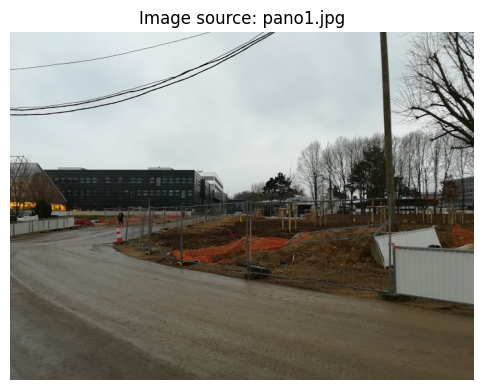

In [18]:
data_path = './Data/'

image_files = [f for f in os.listdir(data_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
image_files.sort()

print("Images disponibles:")
for i, img_file in enumerate(image_files):
    print(f"{i}: {img_file}")

images = {}
for img_file in image_files:
    img = cv2.imread(os.path.join(data_path, img_file))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images[img_file] = img_rgb
        print(f"Image {img_file} chargée - Shape: {img_rgb.shape}")

source_name = 'pano1.jpg'
destination_names = ['pano2.jpg']

img_source_bgr = cv2.imread(os.path.join(data_path, source_name))
img_source = images[source_name]

print(f"\nImage source: {source_name}")
print(f"Images destination: {destination_names}")

plt.figure(figsize=(12, 4))
plt.imshow(img_source)
plt.title(f"Image source: {source_name}")
plt.axis('off')
plt.tight_layout()
plt.show()

### Deuxième étape : calcul des points d'intérêts et de leur description

Vous pouvez pour cette étape tester plusieurs des approches existantes et disponibles dans la bibliothèque OpenCV comme :
+ SIFT (scale-invariant feature transform) : voir [ici](https://docs.opencv.org/master/da/df5/tutorial_py_sift_intro.html)
+ SURF (Speeded-Up Robust Features) : très proche de SIFT mais avec une implementation qui permet le calcul des points et des descripteurs de manière rapide (voir [ici](https://docs.opencv.org/master/df/dd2/tutorial_py_surf_intro.html)).
+ ORBFASTBRIEF (Oriented FAST and Rotated BRIEF) est un descripteur binaire rapide basé sur la combinaison du détecteur de points clés FAST (Features from Accelerated Segment Test) et du descripteur BRIEF (Binary robust independent elementary features). Il est invariant en rotation et robuste au bruit. Il a été développé dans les laboratoires OpenCV et constitue une alternative efficace et gratuite à SIFT. (voir [ici](https://docs.opencv.org/4.5.1/d1/d89/tutorial_py_orb.html))



Image source (pano1.jpg):
  - Nombre de points d'intérêt: 1310
  - Descripteurs shape: (1310, 128)

Image destination (pano2.jpg):
  - Nombre de points d'intérêt: 1141
  - Descripteurs shape: (1141, 128)


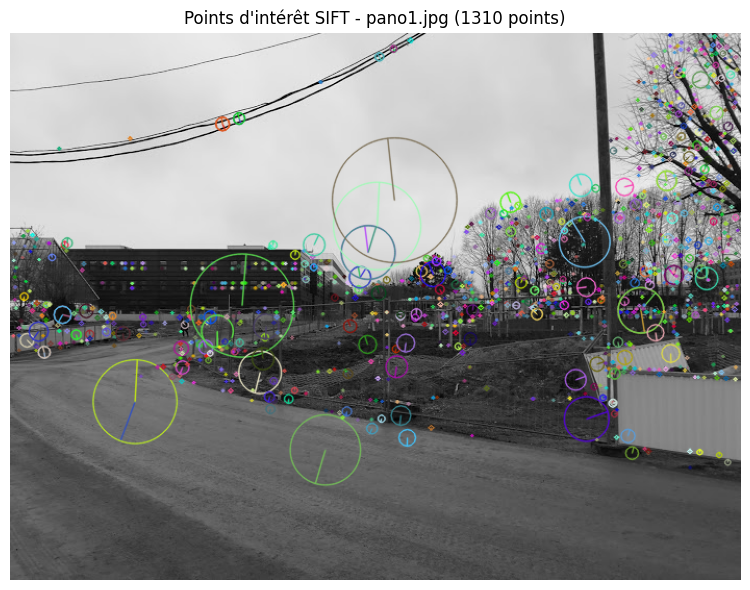

In [19]:
sift = cv2.SIFT_create()

keypoints_desc = {}

img_source_gray = cv2.cvtColor(img_source_bgr, cv2.COLOR_BGR2GRAY)
kp_source, des_source = sift.detectAndCompute(img_source_gray, None)
keypoints_desc[source_name] = {'keypoints': kp_source, 'descriptors': des_source, 'gray': img_source_gray}

print(f"Image source ({source_name}):")
print(f"  - Nombre de points d'intérêt: {len(kp_source)}")
print(f"  - Descripteurs shape: {des_source.shape}")

for dest_name in destination_names:
    img_dest_bgr = cv2.imread(os.path.join(data_path, dest_name))
    img_dest_gray = cv2.cvtColor(img_dest_bgr, cv2.COLOR_BGR2GRAY)
    kp_dest, des_dest = sift.detectAndCompute(img_dest_gray, None)
    keypoints_desc[dest_name] = {'keypoints': kp_dest, 'descriptors': des_dest, 'bgr': img_dest_bgr, 'gray': img_dest_gray}
    
    print(f"\nImage destination ({dest_name}):")
    print(f"  - Nombre de points d'intérêt: {len(kp_dest)}")
    print(f"  - Descripteurs shape: {des_dest.shape}")

img_source_kp = cv2.drawKeypoints(img_source_gray, kp_source, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_source_kp_rgb = cv2.cvtColor(img_source_kp, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(img_source_kp_rgb)
plt.title(f"Points d'intérêt SIFT - {source_name} ({len(kp_source)} points)")
plt.axis('off')
plt.tight_layout()
plt.show()

### Troisième étape : Recherche des paires correspondantes

Il s'agit maintenant de trouver les paires correspondantes candidates entre deux images. Ici aussi plusieurs approches sont possibles comme par exemple [`BFMatcher.knnMatch`](https://docs.opencv.org/master/dc/dc3/tutorial_py_matcher.html). Cette approche mesure la distance entre chaque paire de descripteurs de points clés et renvoie pour chaque point clé ses k meilleures correspondances avec la distance minimale.

Il est nécessaire ensuite d'appliquer un filtre de ratio pour ne garder que les correspondances correctes. En effet, pour obtenir une correspondance fiable, les points clés appariés doivent être significativement plus proches que la correspondance incorrecte la plus proche.



Matching avec pano2.jpg:
  - Nombre de correspondances trouvées: 1310
  - Bonnes correspondances après filtre de ratio: 200


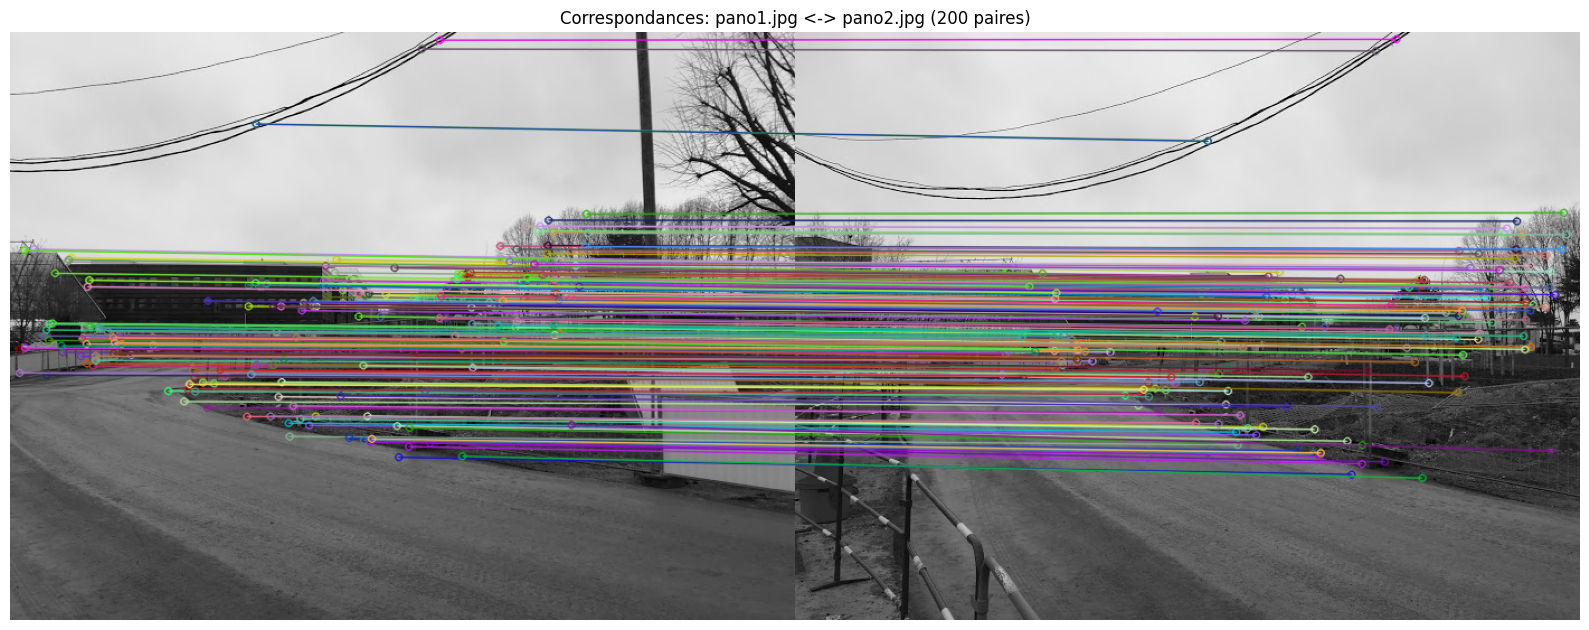

In [20]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

matches_dict = {}

for dest_name in destination_names:
    des_dest = keypoints_desc[dest_name]['descriptors']
    
    matches = bf.knnMatch(des_source, des_dest, k=2)
    
    print(f"\nMatching avec {dest_name}:")
    print(f"  - Nombre de correspondances trouvées: {len(matches)}")
    
    good_matches = []
    for pair in matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.7 * n.distance:
                good_matches.append(m)
    
    good_matches = sorted(good_matches, key=lambda x: x.distance)[:200]
    
    matches_dict[dest_name] = good_matches
    
    print(f"  - Bonnes correspondances après filtre de ratio: {len(good_matches)}")
    
    if len(good_matches) > 0:
        img_dest_rgb = cv2.cvtColor(keypoints_desc[dest_name]['bgr'], cv2.COLOR_BGR2RGB)
        img_matches = cv2.drawMatches(
            img_source_gray, 
            keypoints_desc[source_name]['keypoints'],
            keypoints_desc[dest_name]['gray'], 
            keypoints_desc[dest_name]['keypoints'],
            good_matches, 
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS
        )
        img_matches_rgb = cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(16, 8))
        plt.imshow(img_matches_rgb)
        plt.title(f"Correspondances: {source_name} <-> {dest_name} ({len(good_matches)} paires)")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

### Quatrième étape : Calcul de l'homographie 

Après avoir fait correspondre au moins quatre paires de points clés, nous pouvons transformer une image par rapport à l'autre. Cette opération est appelée déformation d'image (**image warping**). Deux images d'une même surface plane dans l'espace sont reliées par une homographie. Les homographies sont des transformations géométriques qui ont 8 paramètres libres et sont représentées par une matrice 3x3. Elles représentent toute distorsion apportée à une image dans son ensemble (par opposition aux déformations locales). Par conséquent, pour obtenir l'image détectée transformée, il faut calculer la matrice d'homographie et l'appliquer à l'image détectée.

L'algorithme RANSAC peut etre utiliser pour détecter les valeurs aberrantes et les éliminer avant de déterminer l'homographie finale. Il est directement intégré à la méthode [`findHomography`](https://docs.opencv.org/master/d1/de0/tutorial_py_feature_homography.html) d'OpenCV. 




In [21]:
homographies = {}

for dest_name in destination_names:
    good_matches = matches_dict[dest_name]
    
    if len(good_matches) >= 4:
        src_pts = np.float32([
            keypoints_desc[source_name]['keypoints'][m.queryIdx].pt 
            for m in good_matches
        ]).reshape(-1, 1, 2)
        
        dst_pts = np.float32([
            keypoints_desc[dest_name]['keypoints'][m.trainIdx].pt 
            for m in good_matches
        ]).reshape(-1, 1, 2)
        
        H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
        
        matches_inliers = np.sum(mask)
        print(f"\nHomographie pour {dest_name}:")
        print(f"  - Nombre de correspondances utilisées: {len(good_matches)}")
        print(f"  - Nombre de points inliers (RANSAC): {matches_inliers}")
        print(f"  - Matrice d'homographie:")
        print(H)
        
        homographies[dest_name] = {
            'H': H,
            'mask': mask,
            'src_pts': src_pts,
            'dst_pts': dst_pts
        }
    else:
        print(f"\nErreur: Pas assez de correspondances pour {dest_name} (minimum 4 requis)")
        print(f"  - Nombre de correspondances: {len(good_matches)}")


Homographie pour pano2.jpg:
  - Nombre de correspondances utilisées: 200
  - Nombre de points inliers (RANSAC): 193
  - Matrice d'homographie:
[[ 1.47332758e+00 -3.18867905e-02 -2.53785795e+02]
 [ 1.62290742e-01  1.28848406e+00 -8.13095355e+01]
 [ 6.66636769e-04  1.32028433e-05  1.00000000e+00]]


### Cinquième étape : déformation des images

Appliquer une transformation de déformation en utilisant la matrice d'homographie obtenue


Déformation appliquée pour pano2.jpg:
  - Taille image source: (526, 702)
  - Taille image destination: (526, 702)
  - Bounding box du panorama: x=[-269, 702], y=[-82, 593]
  - Taille du canevas étendu: (675, 971)


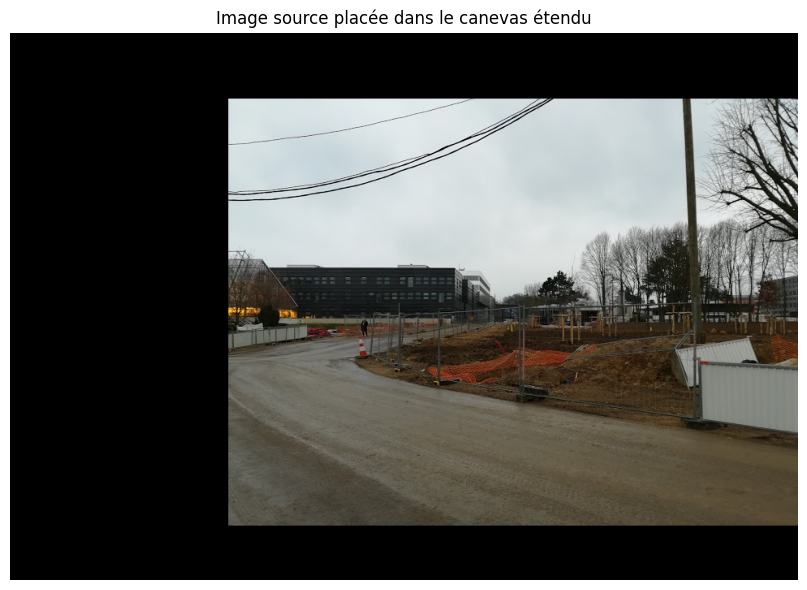

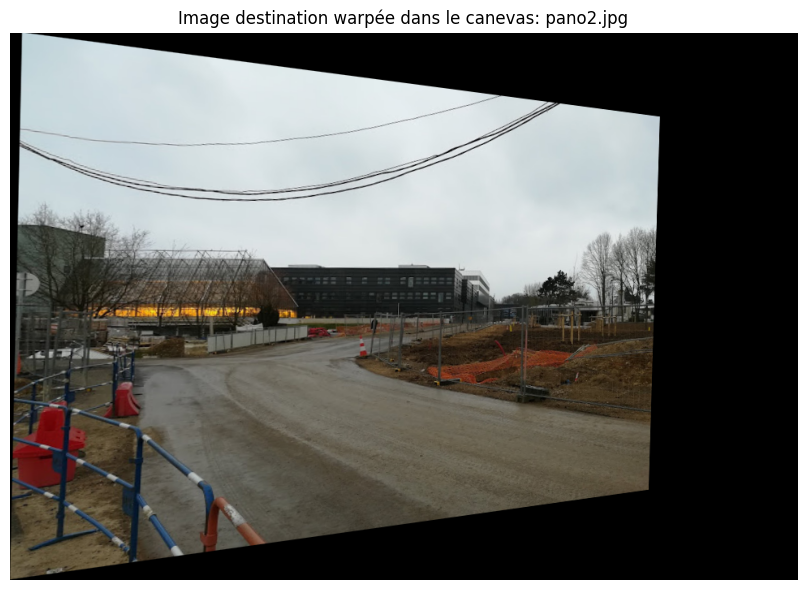

In [22]:
warped_images = {}

for dest_name in destination_names:
    if dest_name in homographies:
        h_data = homographies[dest_name]
        H = h_data['H']
        
        img_dest_bgr = keypoints_desc[dest_name]['bgr']
        h_dest, w_dest = img_dest_bgr.shape[:2]
        h_source, w_source = img_source_bgr.shape[:2]
        
        corners_dest = np.array([
            [0, 0],
            [w_dest, 0],
            [w_dest, h_dest],
            [0, h_dest]
        ], dtype=np.float32)
        
        corners_transformed = cv2.perspectiveTransform(corners_dest.reshape(-1, 1, 2), H).reshape(-1, 2)
        
        all_points = np.vstack([
            [[0, 0], [w_source, 0], [w_source, h_source], [0, h_source]],
            corners_transformed
        ])
        
        min_x = int(np.floor(all_points[:, 0].min()))
        min_y = int(np.floor(all_points[:, 1].min()))
        max_x = int(np.ceil(all_points[:, 0].max()))
        max_y = int(np.ceil(all_points[:, 1].max()))
        
        canvas_width = max_x - min_x
        canvas_height = max_y - min_y
        
        print(f"\nDéformation appliquée pour {dest_name}:")
        print(f"  - Taille image source: ({h_source}, {w_source})")
        print(f"  - Taille image destination: ({h_dest}, {w_dest})")
        print(f"  - Bounding box du panorama: x=[{min_x}, {max_x}], y=[{min_y}, {max_y}]")
        print(f"  - Taille du canevas étendu: ({canvas_height}, {canvas_width})")
        
        translation_matrix = np.array([
            [1, 0, -min_x],
            [0, 1, -min_y]
        ], dtype=np.float32)
        
        img_source_in_canvas = cv2.warpAffine(
            img_source_bgr,
            translation_matrix,
            (canvas_width, canvas_height),
            borderValue=(0, 0, 0)
        )
        
        translation_matrix_3x3 = np.array([
            [1, 0, -min_x],
            [0, 1, -min_y],
            [0, 0, 1]
        ], dtype=np.float32)
        
        H_3x3 = np.vstack([H, [0, 0, 1]]) if H.shape[0] == 2 else H
        H_adjusted = np.dot(translation_matrix_3x3, H_3x3)
        
        img_dest_warped = cv2.warpPerspective(
            img_dest_bgr,
            H_adjusted,
            (canvas_width, canvas_height),
            borderValue=(0, 0, 0)
        )
        
        warped_images[dest_name] = {
            'source_in_canvas': img_source_in_canvas,
            'dest_warped': img_dest_warped,
            'canvas_size': (canvas_width, canvas_height)
        }
        
        img_source_canvas_rgb = cv2.cvtColor(img_source_in_canvas, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 6))
        plt.imshow(img_source_canvas_rgb)
        plt.title(f"Image source placée dans le canevas étendu")
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        img_dest_warped_rgb = cv2.cvtColor(img_dest_warped, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 6))
        plt.imshow(img_dest_warped_rgb)
        plt.title(f"Image destination warpée dans le canevas: {dest_name}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

Appliquer votre chaîne aux différentes imahes collectées. Que contastez vous? Quels types d'améliorations proposeriez vous ?


Pour aller plus loin, voir :
+ https://www.pyimagesearch.com/2018/12/17/image-stitching-with-opencv-and-python/


Panorama créé:
  - Taille: (675, 971, 3)


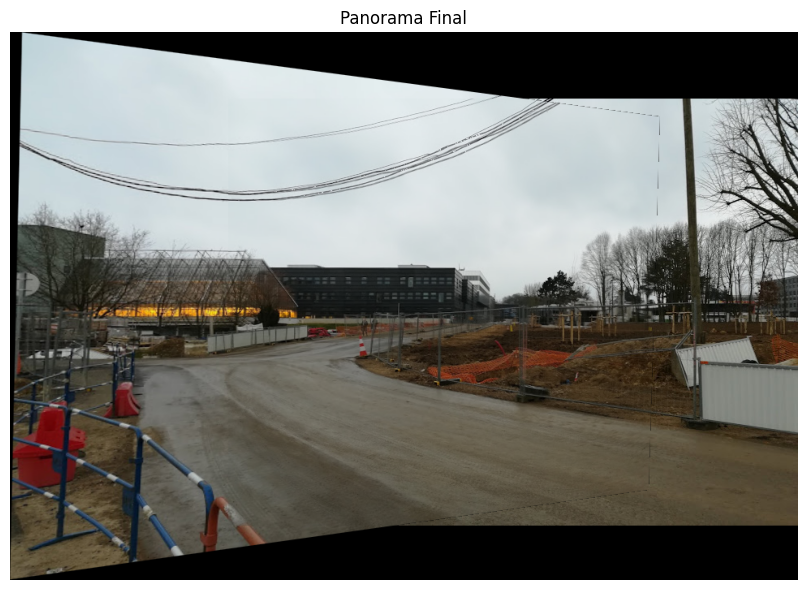

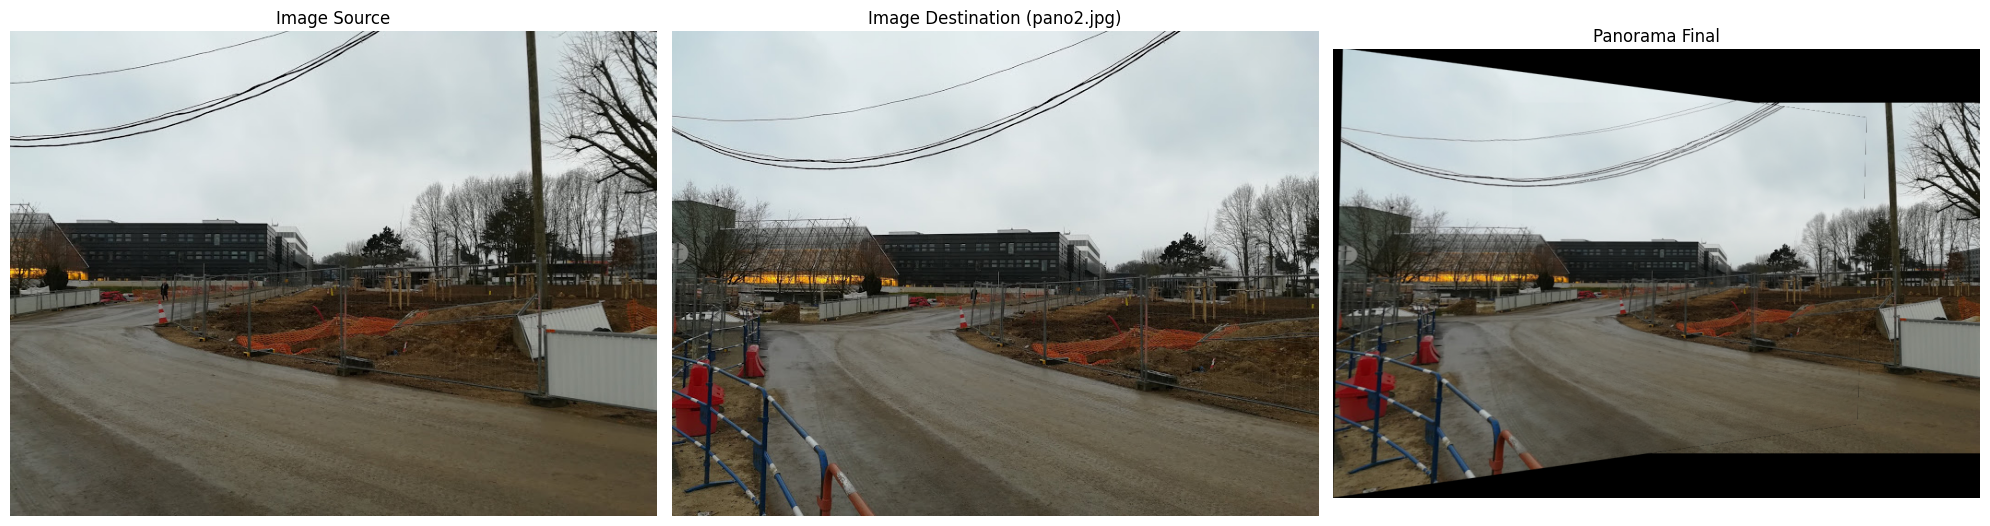


Panorama sauvegardé à: ./Figs/panorama_result.jpg


In [23]:
panorama = None

for dest_name in destination_names:
    if dest_name in warped_images:
        img_source_canvas = warped_images[dest_name]['source_in_canvas'].astype(np.float32)
        img_dest_canvas = warped_images[dest_name]['dest_warped'].astype(np.float32)
        canvas_size = warped_images[dest_name]['canvas_size']
        
        canvas_height, canvas_width = img_source_canvas.shape[:2]
        
        panorama = np.zeros((canvas_height, canvas_width, 3), dtype=np.float32)
        
        img_source_gray = cv2.cvtColor(img_source_canvas.astype(np.uint8), cv2.COLOR_BGR2GRAY)
        img_dest_gray = cv2.cvtColor(img_dest_canvas.astype(np.uint8), cv2.COLOR_BGR2GRAY)
        
        mask_source = (img_source_gray > 0).astype(np.float32)
        mask_dest = (img_dest_gray > 0).astype(np.float32)
        
        mask_source_3ch = np.dstack([mask_source, mask_source, mask_source])
        mask_dest_3ch = np.dstack([mask_dest, mask_dest, mask_dest])
        
        overlap = (mask_source > 0) & (mask_dest > 0)
        overlap_3ch = np.dstack([overlap, overlap, overlap])
        
        panorama[mask_source_3ch > 0] = img_source_canvas[mask_source_3ch > 0]
        
        panorama[overlap_3ch] = (img_source_canvas[overlap_3ch] + img_dest_canvas[overlap_3ch]) / 2
        
        only_dest_3ch = (mask_dest_3ch > 0) & (mask_source_3ch == 0)
        panorama[only_dest_3ch] = img_dest_canvas[only_dest_3ch]

panorama = np.clip(panorama, 0, 255).astype(np.uint8)

print(f"Panorama créé:")
print(f"  - Taille: {panorama.shape}")

panorama_rgb = cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(16, 6))
plt.imshow(panorama_rgb)
plt.title("Panorama Final")
plt.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(cv2.cvtColor(img_source_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Image Source")
axes[0].axis('off')

if destination_names and destination_names[0] in keypoints_desc:
    axes[1].imshow(cv2.cvtColor(keypoints_desc[destination_names[0]]['bgr'], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Image Destination ({destination_names[0]})")
axes[1].axis('off')

axes[2].imshow(panorama_rgb)
axes[2].set_title("Panorama Final")
axes[2].axis('off')

plt.tight_layout()
plt.show()

output_path = './Figs/panorama_result.jpg'
cv2.imwrite(output_path, panorama)
print(f"\nPanorama sauvegardé à: {output_path}")